In [ ]:
# Retail Customer Intelligence & Revenue Optimization

## Business Objective

The objective of this project is to analyze retail customer shopping behavior
to identify customer-value patterns, purchasing behavior, product performance,
promotional engagement, subscription behavior, and customer experience insights.

The analysis uses Python for data preparation and exploratory analysis,
SQL for structured business analysis, and Power BI for interactive reporting.

### Key Business Areas

- Customer intelligence
- Customer value
- Product and category performance
- Discount and promotional behavior
- Subscription adoption
- Purchase frequency
- Customer satisfaction
- Shipping and payment preferences


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

df = pd.read_csv("customer_shopping_behavior.csv")

In [64]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [65]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [66]:
df.shape

(3900, 18)

In [67]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [68]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [71]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Review Rating    37
dtype: int64

In [72]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
Review Rating,37,0.95


In [73]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [74]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [75]:
df.nunique().sort_values()

Promo Code Used              2
Gender                       2
Discount Applied             2
Subscription Status          2
Category                     4
Size                         4
Season                       4
Shipping Type                6
Payment Method               6
Frequency of Purchases       7
Color                       25
Item Purchased              25
Review Rating               26
Location                    50
Previous Purchases          50
Age                         53
Purchase Amount (USD)       81
Customer ID               3900
dtype: int64

In [76]:
df["Gender"].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [77]:
df["Category"].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [78]:
df["Season"].value_counts()

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

In [79]:
df["Subscription Status"].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [80]:
df["Discount Applied"].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

In [81]:
df["Discount Applied"].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

In [82]:
df["Shipping Type"].value_counts()

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64

In [83]:
df["Payment Method"].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [84]:
df["Frequency of Purchases"].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [85]:
df["Age"].min(), df["Age"].max()

(18, 70)

In [86]:
df["Purchase Amount (USD)"].min(), df["Purchase Amount (USD)"].max()

(20, 100)

In [87]:
df["Previous Purchases"].min(), df["Previous Purchases"].max()

(1, 50)

In [88]:
df["Review Rating"].min(), df["Review Rating"].max()

(2.5, 5.0)

In [89]:
boolean_columns = [
    "Subscription Status",
    "Discount Applied",
    "Promo Code Used"
]

for column in boolean_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Subscription Status
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

Discount Applied
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

Promo Code Used
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64


In [90]:
df = df.rename(columns={
    "Customer ID": "customer_id",
    "Age": "age",
    "Gender": "gender",
    "Item Purchased": "item_purchased",
    "Category": "category",
    "Purchase Amount (USD)": "purchase_amount",
    "Location": "location",
    "Size": "size",
    "Color": "color",
    "Season": "season",
    "Review Rating": "review_rating",
    "Subscription Status": "subscription_status",
    "Shipping Type": "shipping_type",
    "Discount Applied": "discount_applied",
    "Promo Code Used": "promo_code_used",
    "Previous Purchases": "previous_purchases",
    "Payment Method": "payment_method",
    "Frequency of Purchases": "purchase_frequency"
})

In [157]:
df["review_rating"] = df.groupby("category")["review_rating"].transform(
    lambda x: x.fillna(x.median())
)

In [158]:
df["review_rating"].isnull().sum()

np.int64(0)

In [159]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'purchase_frequency', 'age_group',
       'subscription_flag', 'discount_flag', 'promo_flag', 'rating_category',
       'purchase_history_segment'],
      dtype='object')

In [160]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,promo_code_used,previous_purchases,payment_method,purchase_frequency,age_group,subscription_flag,discount_flag,promo_flag,rating_category,purchase_history_segment
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,46-55,1,1,1,Average,Moderate
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,18-25,1,1,1,Average,Low
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,46-55,1,1,1,Average,Moderate
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,18-25,1,1,1,Average,Very High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,36-45,1,1,1,Low,High


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               3900 non-null   int64   
 1   age                       3900 non-null   int64   
 2   gender                    3900 non-null   object  
 3   item_purchased            3900 non-null   object  
 4   category                  3900 non-null   object  
 5   purchase_amount           3900 non-null   int64   
 6   location                  3900 non-null   object  
 7   size                      3900 non-null   object  
 8   color                     3900 non-null   object  
 9   season                    3900 non-null   object  
 10  review_rating             3900 non-null   float64 
 11  subscription_status       3900 non-null   object  
 12  shipping_type             3900 non-null   object  
 13  discount_applied          3900 non-null   object

In [162]:
df.shape

(3900, 24)

In [163]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-70"
    ]
)

In [164]:
df["age_group"].value_counts().sort_index()

age_group
18-25     571
26-35     742
36-45     729
46-55     753
56-70    1105
Name: count, dtype: int64

In [165]:
df["subscription_flag"] = df["subscription_status"].map({
    "Yes": 1,
    "No": 0
})

In [166]:
df["discount_flag"] = df["discount_applied"].map({
    "Yes": 1,
    "No": 0
})

In [167]:
df["promo_flag"] = df["promo_code_used"].map({
    "Yes": 1,
    "No": 0
})

In [168]:
df["rating_category"] = pd.cut(
    df["review_rating"],
    bins=[0, 3, 4, 5],
    labels=[
        "Low",
        "Average",
        "High"
    ],
    include_lowest=True
)

In [101]:
df["purchase_history_segment"] = pd.cut(
    df["previous_purchases"],
    bins=[0, 10, 25, 40, 50],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [102]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,promo_code_used,previous_purchases,payment_method,purchase_frequency,age_group,subscription_flag,discount_flag,promo_flag,rating_category,purchase_history_segment
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,46-55,1,1,1,Average,Moderate
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,18-25,1,1,1,Average,Low
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,46-55,1,1,1,Average,Moderate
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,18-25,1,1,1,Average,Very High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,36-45,1,1,1,Low,High


In [106]:
df.shape

(3900, 24)

In [111]:
df.to_csv(
    "retail_customer_cleaned.csv",
    index=False
)

In [ ]:
# 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to identify patterns, relationships,
and potential business insights within customer shopping behavior.

The analysis focuses on:

- Customer characteristics
- Purchase behavior
- Product and category performance
- Promotional engagement
- Subscription behavior
- Customer satisfaction
- Shipping and payment preferences

In [112]:
total_purchase_value = df["purchase_amount"].sum()

print(f"Total Purchase Value: ${total_purchase_value:,.2f}")

Total Purchase Value: $233,081.00


In [113]:
average_purchase = df["purchase_amount"].mean()

print(f"Average Purchase Amount: ${average_purchase:,.2f}")

Average Purchase Amount: $59.76


In [114]:
unique_customers = df["customer_id"].nunique()

print(f"Unique Customers: {unique_customers}")

Unique Customers: 3900


In [115]:
average_rating = df["review_rating"].mean()

print(f"Average Rating: {average_rating:.2f}")

Average Rating: 3.75


In [116]:
average_previous_purchases = df["previous_purchases"].mean()

print(
    f"Average Previous Purchases: "
    f"{average_previous_purchases:.2f}"
)

Average Previous Purchases: 25.35


In [117]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Purchase Value",
        "Average Purchase Amount",
        "Unique Customers",
        "Average Rating",
        "Average Previous Purchases"
    ],
    "Value": [
        total_purchase_value,
        average_purchase,
        unique_customers,
        average_rating,
        average_previous_purchases
    ]
})

kpi_summary

,Metric,Value
0,Total Purchase Value,233081.000000
1,Average Purchase Amount,59.764359
2,Unique Customers,3900.000000
3,Average Rating,3.750065
4,Average Previous Purchases,25.351538


In [118]:
gender_distribution = df["gender"].value_counts()

gender_distribution

gender
Male      2652
Female    1248
Name: count, dtype: int64

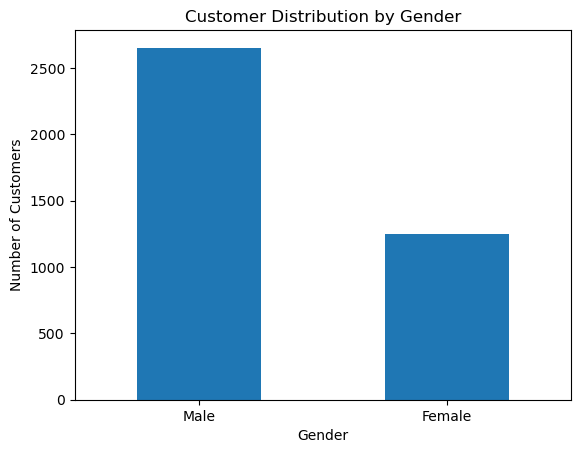

In [119]:
gender_distribution.plot(
    kind="bar",
    title="Customer Distribution by Gender"
)

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [120]:
gender_purchase = (
    df.groupby("gender")["purchase_amount"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

gender_purchase

,count,sum,mean
gender,,,
Male,2652,157890,59.536199
Female,1248,75191,60.249199


In [121]:
age_analysis = (
    df.groupby("age_group", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean")
    )
    .reset_index()
)

age_analysis

,age_group,customers,total_purchase,average_purchase
0,18-25,571,34630,60.647986
1,26-35,742,44342,59.760108
2,36-45,729,43234,59.305898
3,46-55,753,45619,60.583001
4,56-70,1105,65256,59.055204


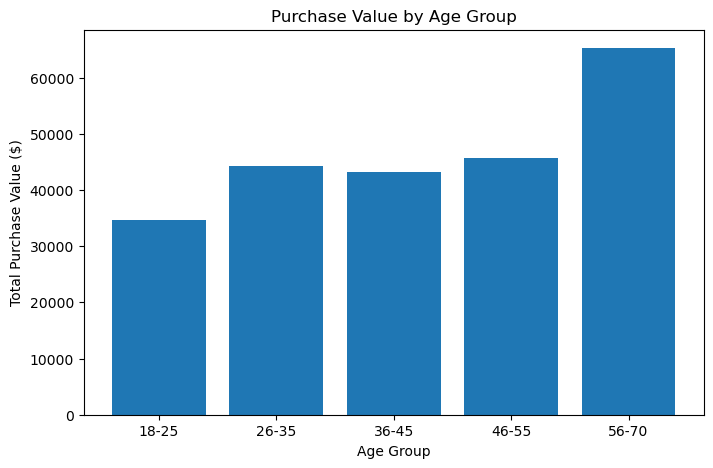

In [122]:
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis["age_group"].astype(str),
    age_analysis["total_purchase"]
)

plt.title("Purchase Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Purchase Value ($)")

plt.show()

In [123]:
frequency_analysis = (
    df.groupby("purchase_frequency")
    .agg(
        customers=("customer_id", "nunique"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean"),
        average_previous_purchases=("previous_purchases", "mean")
    )
    .sort_values("total_purchase", ascending=False)
)

frequency_analysis

,customers,total_purchase,average_purchase,average_previous_purchases
purchase_frequency,,,,
Every 3 Months,584,35088,60.082192,24.960616
Annually,572,34419,60.173077,24.561189
Quarterly,563,33771,59.984014,26.854352
Bi-Weekly,547,33200,60.694698,24.787934
Monthly,553,32810,59.330922,25.278481
Fortnightly,542,32007,59.053506,25.271218
Weekly,539,31786,58.972171,25.771800


In [169]:
previous_purchase_analysis = (
    df.groupby("purchase_history_segment", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        average_purchase=("purchase_amount", "mean"),
        total_purchase=("purchase_amount", "sum"),
        average_previous_purchases=("previous_purchases", "mean")
    )
    .reset_index()
)

previous_purchase_analysis

,purchase_history_segment,customers,average_purchase,total_purchase,average_previous_purchases
0,Low,784,60.668367,47564,5.302296
1,Moderate,1181,58.895004,69555,18.058425
2,High,1170,59.292308,69372,32.945299
3,Very High,765,60.901961,46590,45.543791


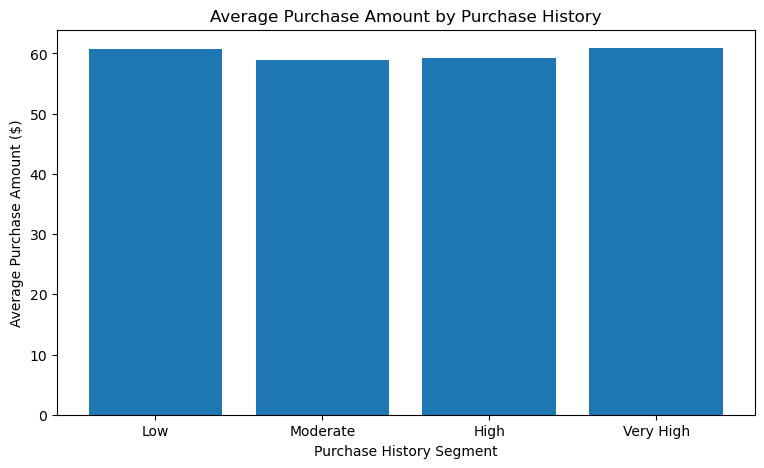

In [170]:
plt.figure(figsize=(9,5))

plt.bar(
    previous_purchase_analysis["purchase_history_segment"].astype(str),
    previous_purchase_analysis["average_purchase"]
)

plt.title("Average Purchase Amount by Purchase History")
plt.xlabel("Purchase History Segment")
plt.ylabel("Average Purchase Amount ($)")

plt.show()

In [171]:
category_analysis = (
    df.groupby("category")
    .agg(
        purchases=("customer_id", "count"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean"),
        average_rating=("review_rating", "mean")
    )
    .sort_values("total_purchase", ascending=False)
)

category_analysis

,purchases,total_purchase,average_purchase,average_rating
category,,,,
Clothing,1737,104264,60.025331,3.721301
Accessories,1240,74200,59.838710,3.770242
Footwear,599,36093,60.255426,3.793823
Outerwear,324,18524,57.172840,3.745988


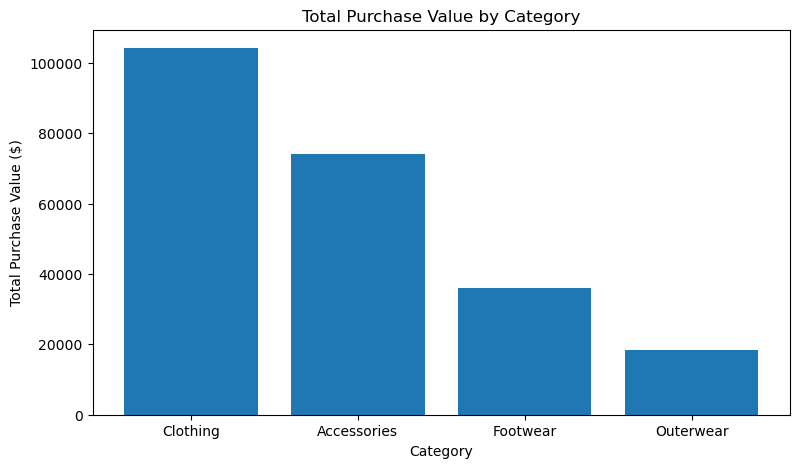

In [172]:
plt.figure(figsize=(9,5))

plt.bar(
    category_analysis.index,
    category_analysis["total_purchase"]
)

plt.title("Total Purchase Value by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Value ($)")

plt.show()

In [173]:
category_rating = (
    df.groupby("category")["review_rating"]
    .mean()
    .sort_values(ascending=False)
)

category_rating

category
Footwear       3.793823
Accessories    3.770242
Outerwear      3.745988
Clothing       3.721301
Name: review_rating, dtype: float64

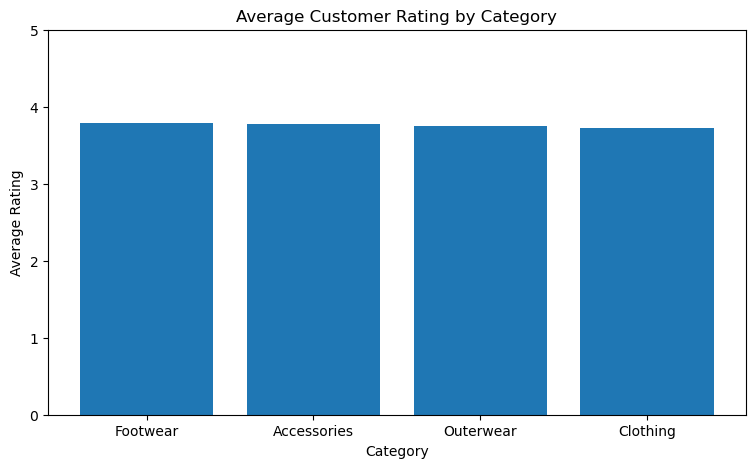

In [174]:
plt.figure(figsize=(9,5))

plt.bar(
    category_rating.index,
    category_rating.values
)

plt.title("Average Customer Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.show()

In [175]:
top_products = (
    df.groupby("item_purchased")
    .agg(
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean"),
        average_rating=("review_rating", "mean"),
        purchases=("customer_id", "count")
    )
    .sort_values("total_purchase", ascending=False)
    .head(10)
)

top_products

,total_purchase,average_purchase,average_rating,purchases
item_purchased,,,,
Blouse,10410,60.877193,3.680702,171
Shirt,10332,61.136095,3.622485,169
Dress,10320,62.168675,3.749398,166
Pants,10090,59.005848,3.720468,171
Jewelry,10010,58.538012,3.759064,171
Sunglasses,9649,59.931677,3.752174,161
Belt,9635,59.844720,3.763975,161
Scarf,9561,60.898089,3.707006,157
Sweater,9462,57.695122,3.759756,164


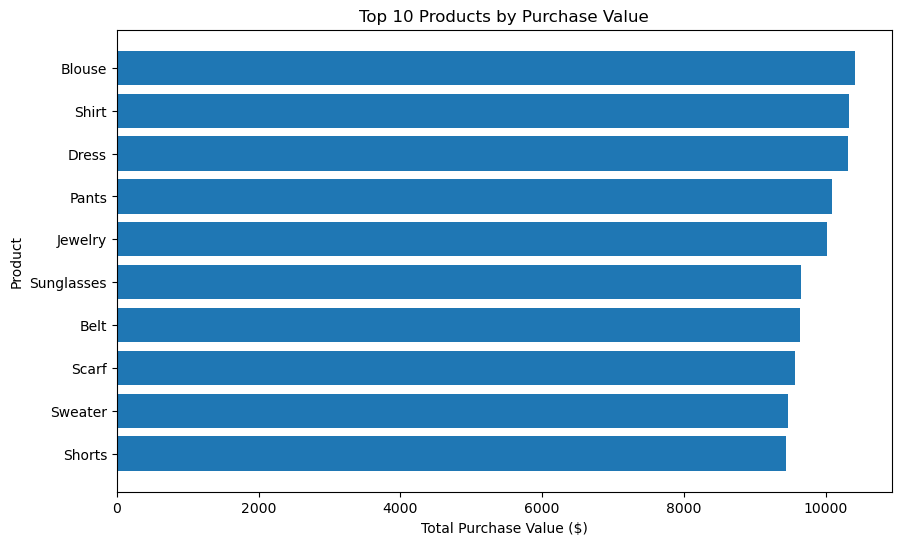

In [176]:
plt.figure(figsize=(10,6))

plt.barh(
    top_products.index,
    top_products["total_purchase"]
)

plt.title("Top 10 Products by Purchase Value")
plt.xlabel("Total Purchase Value ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [177]:
discount_analysis = (
    df.groupby("discount_applied")
    .agg(
        purchases=("customer_id", "count"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean")
    )
)

discount_analysis

,purchases,total_purchase,average_purchase
discount_applied,,,
No,2223,133670,60.130454
Yes,1677,99411,59.279070


In [178]:
discount_analysis["purchase_share_%"] = (
    discount_analysis["purchases"]
    / discount_analysis["purchases"].sum()
    * 100
)

discount_analysis

,purchases,total_purchase,average_purchase,purchase_share_%
discount_applied,,,,
No,2223,133670,60.130454,57.0
Yes,1677,99411,59.279070,43.0


In [179]:
promo_analysis = (
    df.groupby("promo_code_used")
    .agg(
        purchases=("customer_id", "count"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean")
    )
)

promo_analysis

,purchases,total_purchase,average_purchase
promo_code_used,,,
No,2223,133670,60.130454
Yes,1677,99411,59.279070


In [180]:
subscription_analysis = (
    df.groupby("subscription_status")
    .agg(
        customers=("customer_id", "nunique"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean"),
        average_previous_purchases=("previous_purchases", "mean"),
        average_rating=("review_rating", "mean")
    )
)

subscription_analysis

,customers,total_purchase,average_purchase,average_previous_purchases,average_rating
subscription_status,,,,,
No,2847,170436,59.865121,25.080436,3.751001
Yes,1053,62645,59.491928,26.084520,3.747483


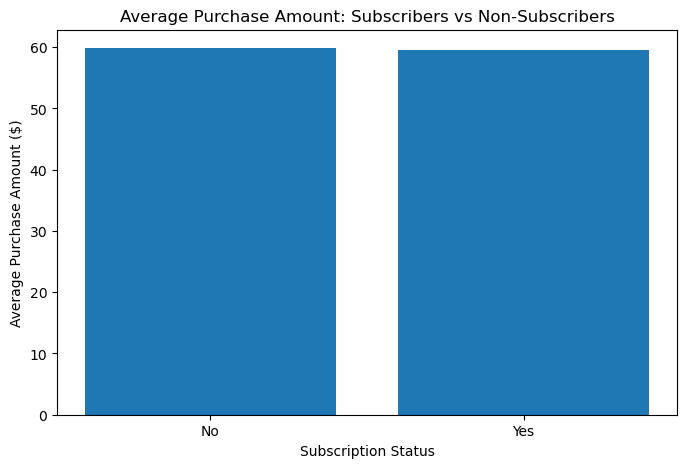

In [181]:
plt.figure(figsize=(8,5))

plt.bar(
    subscription_analysis.index,
    subscription_analysis["average_purchase"]
)

plt.title("Average Purchase Amount: Subscribers vs Non-Subscribers")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount ($)")

plt.show()

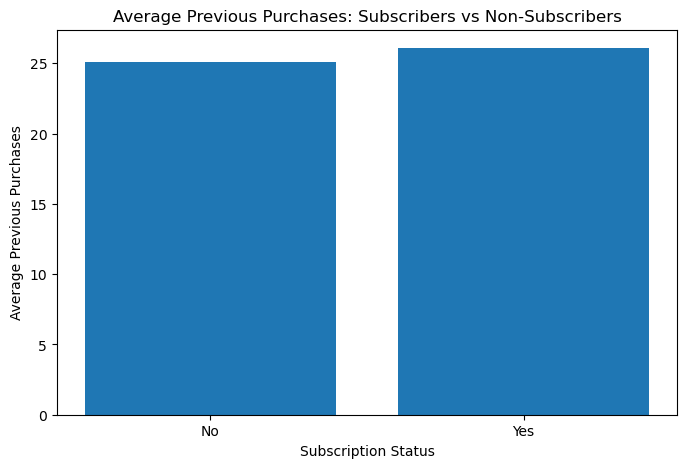

In [182]:
plt.figure(figsize=(8,5))

plt.bar(
    subscription_analysis.index,
    subscription_analysis["average_previous_purchases"]
)

plt.title("Average Previous Purchases: Subscribers vs Non-Subscribers")
plt.xlabel("Subscription Status")
plt.ylabel("Average Previous Purchases")

plt.show()

In [183]:
rating_summary = df["review_rating"].describe()

rating_summary

count    3900.000000
mean        3.750051
std         0.713590
min         2.500000
25%         3.100000
50%         3.800000
75%         4.400000
max         5.000000
Name: review_rating, dtype: float64

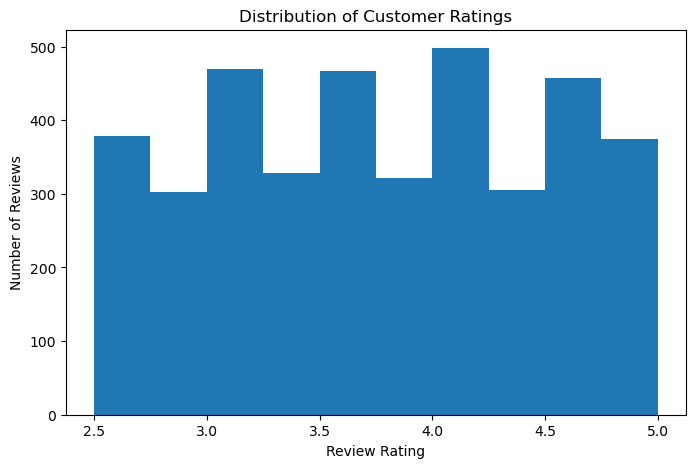

In [184]:
plt.figure(figsize=(8,5))

plt.hist(
    df["review_rating"],
    bins=10
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [185]:
shipping_analysis = (
    df.groupby("shipping_type")
    .agg(
        purchases=("customer_id", "count"),
        average_purchase=("purchase_amount", "mean"),
        average_rating=("review_rating", "mean")
    )
    .sort_values("purchases", ascending=False)
)

shipping_analysis

,purchases,average_purchase,average_rating
shipping_type,,,
Free Shipping,675,60.410370,3.717037
Standard,654,58.460245,3.818960
Store Pickup,650,59.893846,3.707231
Next Day Air,648,58.631173,3.719753
Express,646,60.475232,3.773065
2-Day Shipping,627,60.733652,3.765710


In [186]:
payment_analysis = (
    df.groupby("payment_method")
    .agg(
        purchases=("customer_id", "count"),
        total_purchase=("purchase_amount", "sum"),
        average_purchase=("purchase_amount", "mean")
    )
    .sort_values("total_purchase", ascending=False)
)

payment_analysis

,purchases,total_purchase,average_purchase
payment_method,,,
Credit Card,671,40310,60.074516
PayPal,677,40109,59.245199
Cash,670,40002,59.704478
Debit Card,636,38742,60.915094
Venmo,634,37374,58.949527
Bank Transfer,612,36544,59.712418


In [187]:
numeric_columns = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,age,purchase_amount,review_rating,previous_purchases
age,1.000000,-0.010424,-0.024463,0.040445
purchase_amount,-0.010424,1.000000,0.029659,0.008063
review_rating,-0.024463,0.029659,1.000000,0.003555
previous_purchases,0.040445,0.008063,0.003555,1.000000


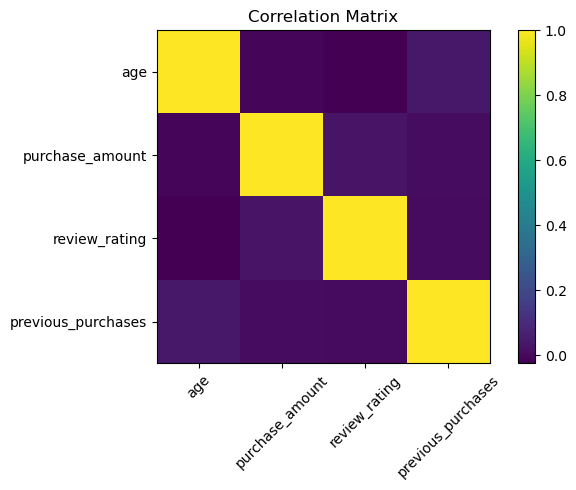

In [188]:
plt.figure(figsize=(7,5))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [189]:
df.to_csv(
    "retail_customer_cleaned.csv",
    index=False
)